# Exploratory Data Analysis

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make the plot look better
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

df = pd.read_csv("../data/novagen_dataset.csv")
print("Dataset loaded successfully!")
print("Shape of the dataset:", df.shape)

Dataset loaded successfully!
Shape of the dataset: (9549, 23)


# first Look


In [5]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [7]:
df.dtypes

Age                      float64
BMI                      float64
Blood_Pressure           float64
Cholesterol              float64
Glucose_Level            float64
Heart_Rate               float64
Sleep_Hours              float64
Exercise_Hours           float64
Water_Intake             float64
Stress_Level             float64
Target                     int64
Smoking                    int64
Alcohol                    int64
Diet                       int64
MentalHealth               int64
PhysicalActivity           int64
MedicalHistory             int64
Allergies                  int64
Diet_Type__Vegan            bool
Diet_Type__Vegetarian       bool
Blood_Group_AB              bool
Blood_Group_B               bool
Blood_Group_O               bool
dtype: object

# Null Values

In [8]:
print("=== NULL VALUE CHECK ===")
null_counts = df.isnull().sum()
print(null_counts)
print(null_counts[null_counts > 0])
print("Total null values:", df.isnull().sum().sum())
print("Total rows :", len(df))

=== NULL VALUE CHECK ===
Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64
Series([], dtype: int64)
Total null values: 0
Total rows : 9549


# Basic Statistics

In [11]:
df.describe().T # .T transposes so it's easier to read

,count,mean,std,min,25%,50%,75%,max
Age,9549.0,33.806786,24.566473,0.0,14.0,29.0,50.0,100.0
BMI,9549.0,25.660697,1.942369,19.0,24.0,26.0,27.0,32.0
Blood_Pressure,9549.0,130.382658,27.878476,22.0,113.0,134.0,150.0,225.0
Cholesterol,9549.0,199.091528,1.969234,192.0,198.0,199.0,200.0,207.0
Glucose_Level,9549.0,100.225678,2.157999,93.0,99.0,100.0,102.0,107.0
Heart_Rate,9549.0,73.613782,1.681538,67.0,73.0,74.0,75.0,80.0
Sleep_Hours,9549.0,6.951409,2.352152,-0.0,5.0,7.0,9.0,14.0
Exercise_Hours,9549.0,1.892345,1.378714,-0.0,1.0,2.0,3.0,8.0
Water_Intake,9549.0,3.580899,1.622874,0.0,2.0,4.0,5.0,10.0
Stress_Level,9549.0,4.382134,2.078593,0.0,3.0,4.0,6.0,12.0


# Class Balance Check

=== CLASS DISTRIBUTION ===
Target
1    4979
0    4570
Name: count, dtype: int64

Percentage:
Target
1    52.141586
0    47.858414
Name: proportion, dtype: float64


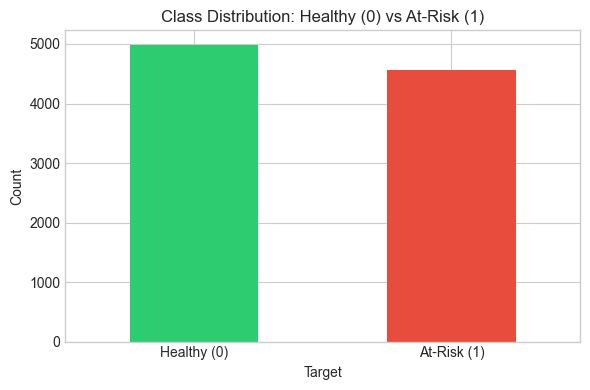

In [14]:
print("=== CLASS DISTRIBUTION ===")
print(df["Target"].value_counts())
print("\nPercentage:")
print(df["Target"].value_counts(normalize=True) * 100)

# Visualize it
plt.figure(figsize=(6, 4))
df["Target"].value_counts().plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Class Distribution: Healthy (0) vs At-Risk (1)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks([0, 1], ["Healthy (0)", "At-Risk (1)"], rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

# Fix the Boolean Bug

In [15]:
# Convert "True"/"False" strings to 1/0 integers
df["Diet_Type__Vegan"] = df["Diet_Type__Vegan"].map({"True": 1, "False" : 0, True: 1, False: 0})
df["Diet_Type__Vegetarian"] = df["Diet_Type__Vegetarian"].map({"True": 1, "False" : 0, True: 1, False: 0})

print("=== UNIQUE VALUES IN DIET TYPE COLUMNS ===")
print("Diet_Type__Vegan:", df["Diet_Type__Vegan"].unique())
print("Diet_Type__Vegetarian:", df["Diet_Type__Vegetarian"].unique())

=== UNIQUE VALUES IN DIET TYPE COLUMNS ===
Diet_Type__Vegan: [0 1]
Diet_Type__Vegetarian: [1 0]


#  Correlation Heatmap

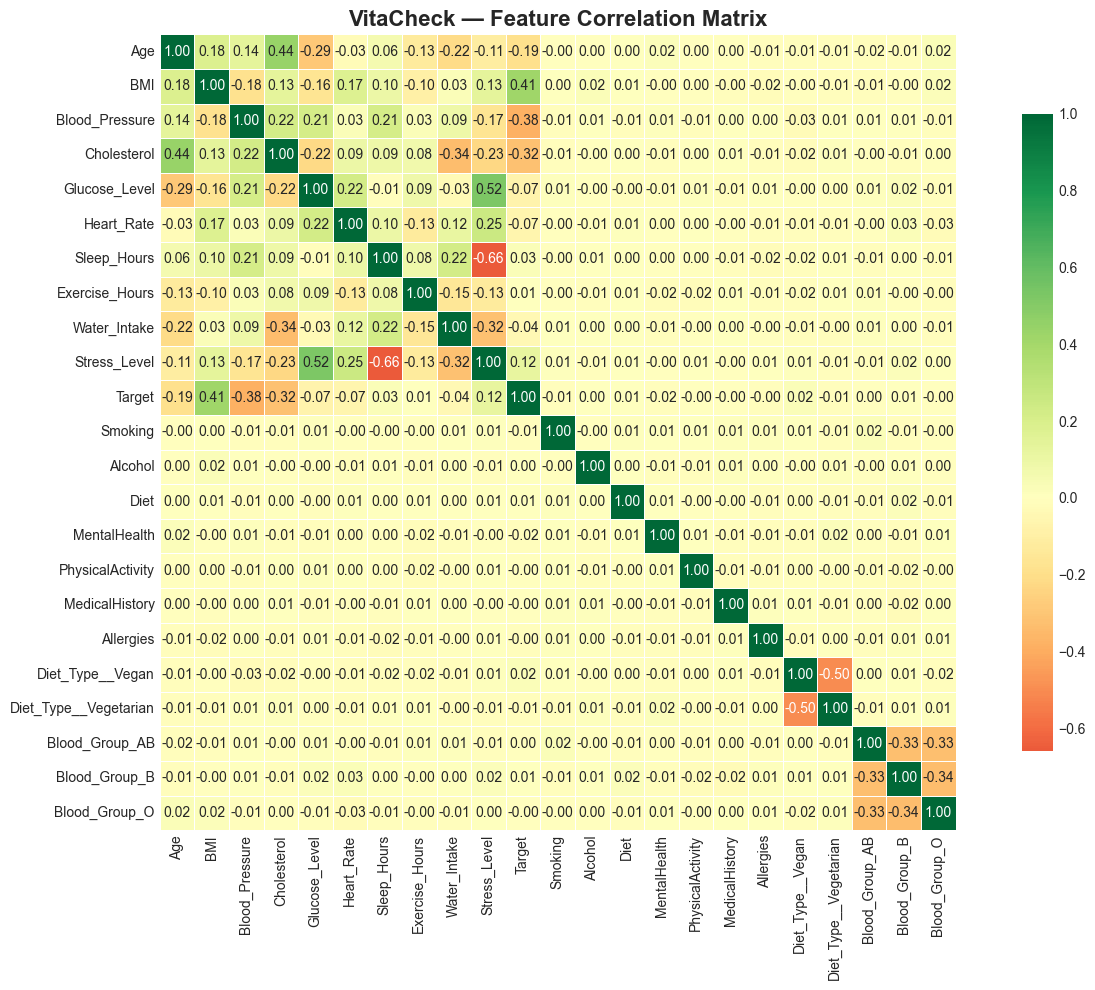

In [20]:
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidth=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("VitaCheck — Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


# Distribution of Key Numerical Features

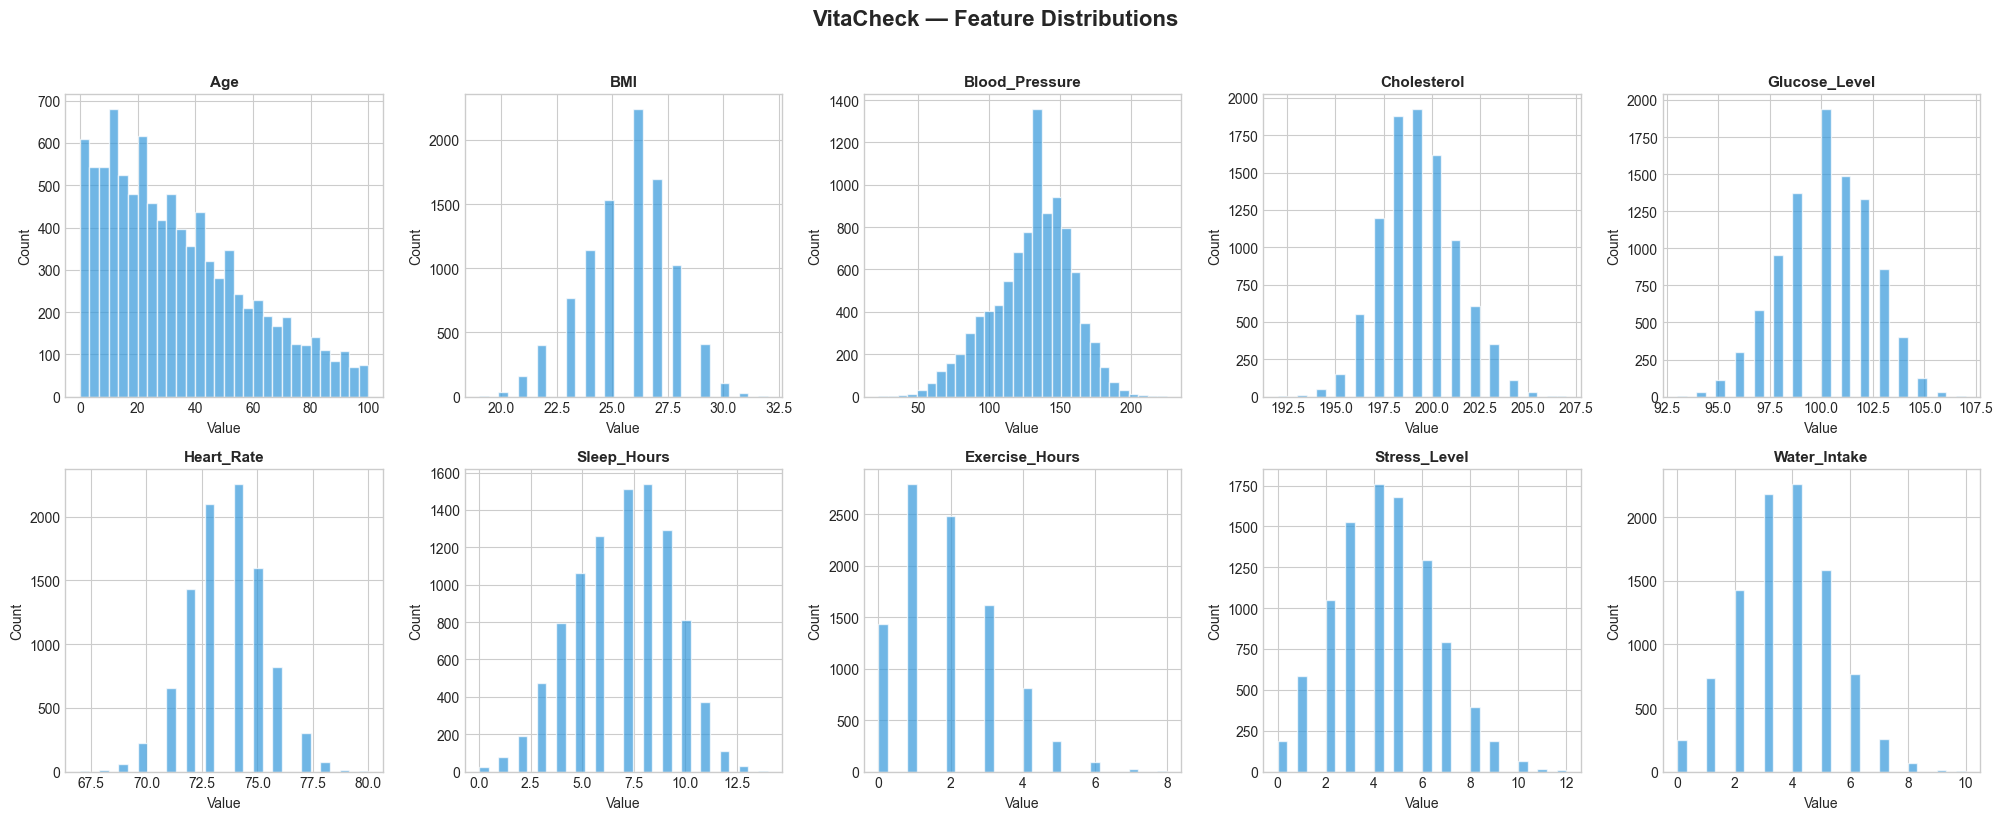

In [23]:
num_features = ["Age", "BMI", "Blood_Pressure", "Cholesterol", "Glucose_Level", "Heart_Rate", "Sleep_Hours", "Exercise_Hours", "Stress_Level", "Water_Intake" ]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color="#3498db", alpha=0.7, edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("VitaCheck — Feature Distributions", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()

plt.savefig("feature_distributions.png", dpi=150)
plt.show()


# Boxplots: Healthy vs At-Risk

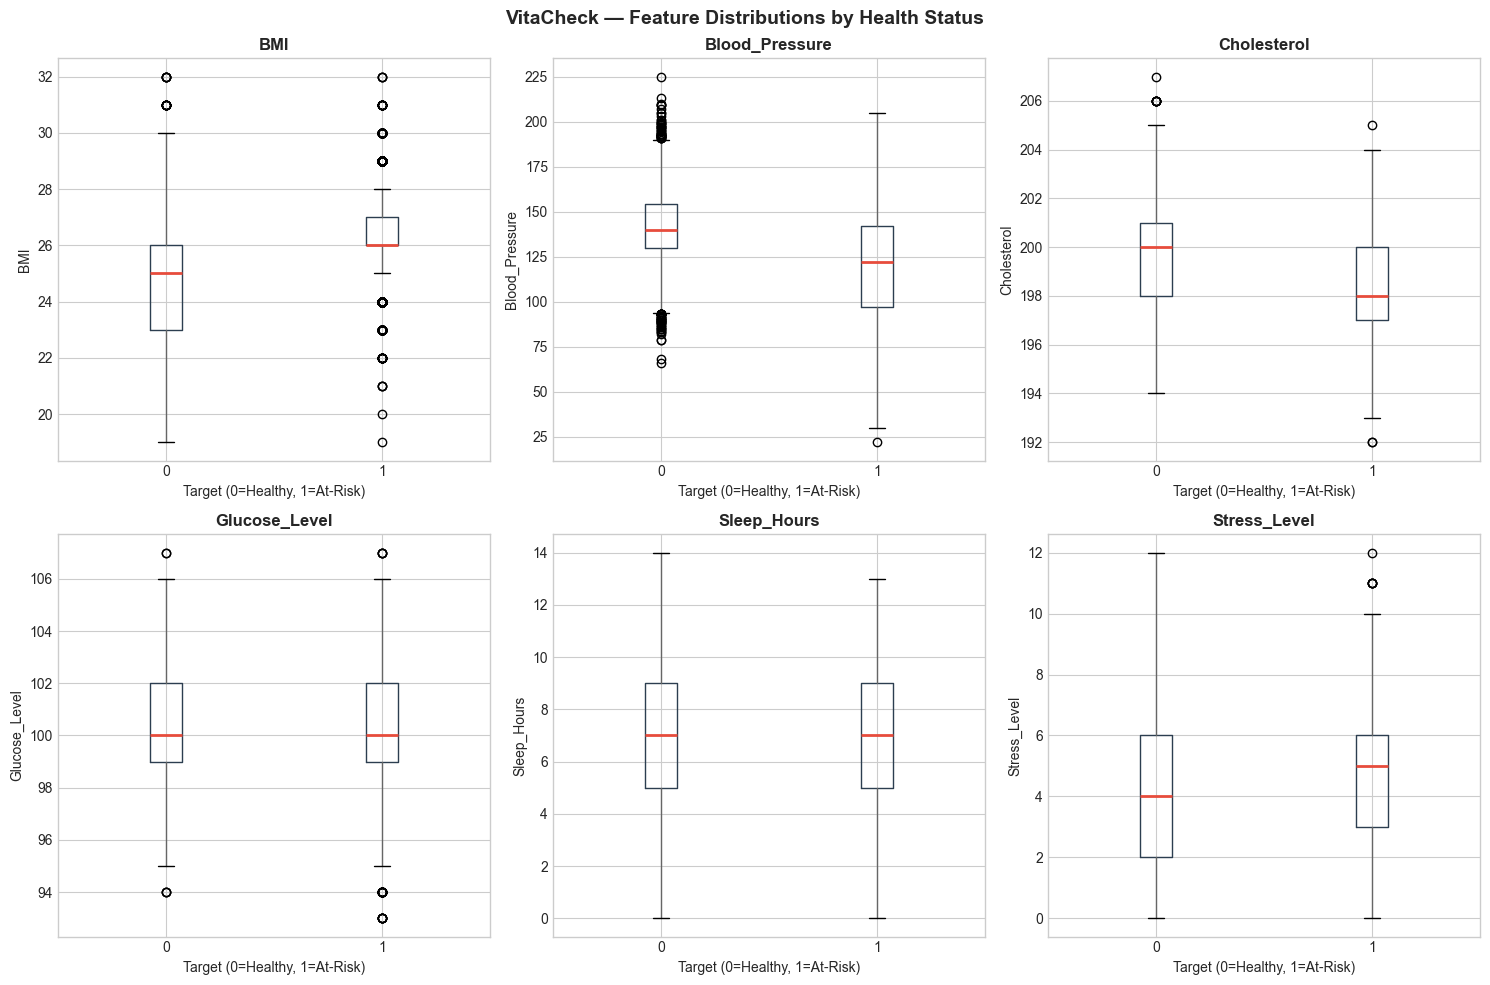

In [27]:
key_features = ["BMI", "Blood_Pressure", "Cholesterol", 
                "Glucose_Level", "Sleep_Hours", "Stress_Level"]


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, by="Target", ax=axes[i], boxprops=dict(color="#2c3e50"), medianprops=dict(color="#e74c3c", linewidth=2))
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Target (0=Healthy, 1=At-Risk)")
    axes[i].set_ylabel(col)

plt.suptitle("VitaCheck — Feature Distributions by Health Status", 
             fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("boxplots_by_target.png", dpi=150)
plt.show()

#  EDA Summary

In [28]:
print("=" * 50)
print("VitaCheck EDA Summary")
print("=" * 50)
print(f"Total records       : {len(df)}")
print(f"Total features      : {df.shape[1] - 1}")
print(f"Healthy (0)         : {(df['Target'] == 0).sum()}")
print(f"At-Risk (1)         : {(df['Target'] == 1).sum()}")
print(f"Null values         : {df.isnull().sum().sum()}")
print(f"Duplicate rows      : {df.duplicated().sum()}")
print("=" * 50)

VitaCheck EDA Summary
Total records       : 9549
Total features      : 22
Healthy (0)         : 4570
At-Risk (1)         : 4979
Null values         : 0
Duplicate rows      : 0
